In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot(time, series, x, y, name):
    if time is not None:
        plt.figure(figsize=(8, 5))
        plt.plot(time, series)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(name)
        plt.grid(True)
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(series)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(name)
        plt.grid(True)
        plt.show()

In [3]:
def to_price(sqrtPriceX96, decimals0 = 18, decimals1 = 18):
    return ((sqrtPriceX96 / (2 ** 96)) ** 2)*10**(decimals0-decimals1)

In [4]:
import json

with open("data_from_David/nect_honey.json", "r") as file:
    data_nect = json.load(file)

display(data_nect)

[{'id': '0x56a5ac11ba0f2c6b887d3e3aa154e3dd9859eac2-235000',
  'liquidity': '0',
  'sqrtPriceX96': '79228162514264337593543950336',
  'blockNumber': '235000',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X128': '0',
  'feeProtocol': '229379500',
  'observationCardinality': 1,
  'observationCardinalityNext': 1,
  'observationIndex': 0,
  'price0USD': '0',
  'price1USD': '0',
  'tick': 0,
  'timestamp': '1737826547',
  'unlocked': True,
  'token0BalanceKodiak': '0',
  'token0BalancePool': '0',
  'token1BalanceKodiak': '0',
  'token1BalancePool': '0',
  'totalSupply': '0',
  'managerToken1BalancerManager': '0',
  'managerToken0BalancerManager': '0',
  'upperTick': 1400,
  'lowerTick': -1400,
  'positionID': '0x7cb6c39709f22acb6fecedd3a66b81dc2a740cc7adc991f468a301620ae5c65e'},
 {'id': '0x56a5ac11ba0f2c6b887d3e3aa154e3dd9859eac2-235100',
  'liquidity': '0',
  'sqrtPriceX96': '79228162514264337593543950336',
  'blockNumber': '235100',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X

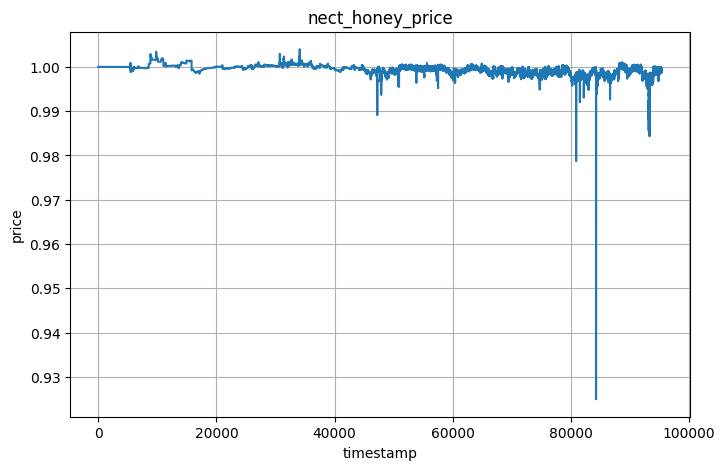

In [5]:
sqrt_prices_nect = [item['sqrtPriceX96'] for item in data_nect]
sqrt_prices_nect = np.array(sqrt_prices_nect).astype(float)

nect_honey_price = to_price(sqrt_prices_nect)

plot(
    None,
    nect_honey_price,
    'timestamp',
    'price',
    'nect_honey_price'
)

In [6]:
with open("data_from_David/wbera_honey.json", "r") as file:
    data_wbera = json.load(file)

display(data_wbera)

[{'id': '0x1127f801cb3ab7bdf8923272949aa7dba94b5805-764300',
  'liquidity': '0',
  'sqrtPriceX96': '235822000800336338346830283647',
  'blockNumber': '764300',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X128': '0',
  'feeProtocol': '229379500',
  'observationCardinality': 1,
  'observationCardinalityNext': 1,
  'observationIndex': 0,
  'price0USD': '0',
  'price1USD': '0',
  'tick': 21816,
  'timestamp': '1738819749',
  'unlocked': True,
  'token0BalanceKodiak': None,
  'token0BalancePool': '5500000000000000000',
  'token1BalanceKodiak': None,
  'token1BalancePool': '959471240369301792659',
  'totalSupply': None,
  'managerToken1BalancerManager': None,
  'managerToken0BalancerManager': None,
  'upperTick': None,
  'lowerTick': None,
  'positionID': None},
 {'id': '0x1127f801cb3ab7bdf8923272949aa7dba94b5805-764400',
  'liquidity': '0',
  'sqrtPriceX96': '235822000800336338346830283647',
  'blockNumber': '764400',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X128': '0',
  'fe

5.460336717130696
6.356507423985449
0.4996346633261583
1739814495.0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9688\2409607011.py:14: RuntimeWarning: invalid value encountered in divide
  wbera_frac = WBERAIslandBalance*wbera_honey_price/(WBERAIslandBalance*wbera_honey_price + HONEYIslandBalance)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9688\2409607011.py:15: RuntimeWarning: invalid value encountered in divide
  nav = (WBERAIslandBalance*wbera_honey_price + HONEYIslandBalance)/total_supply_wbera_honey


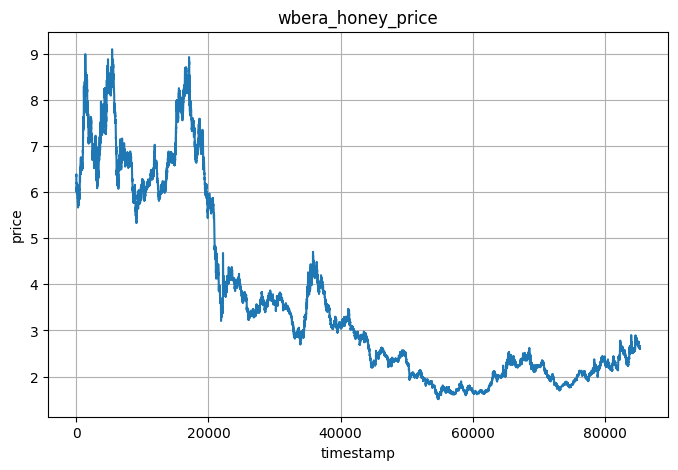

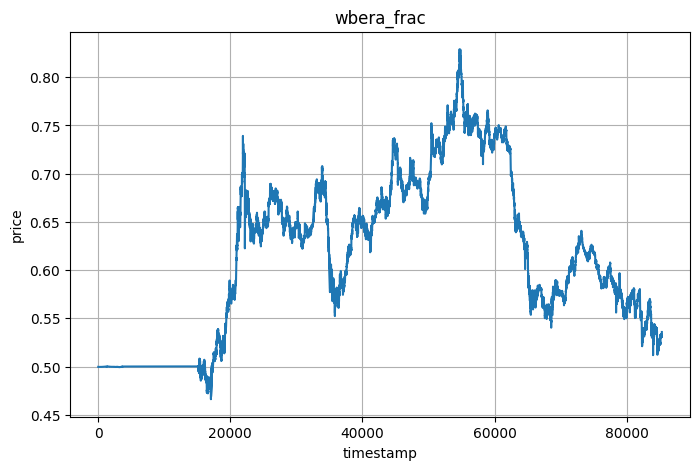

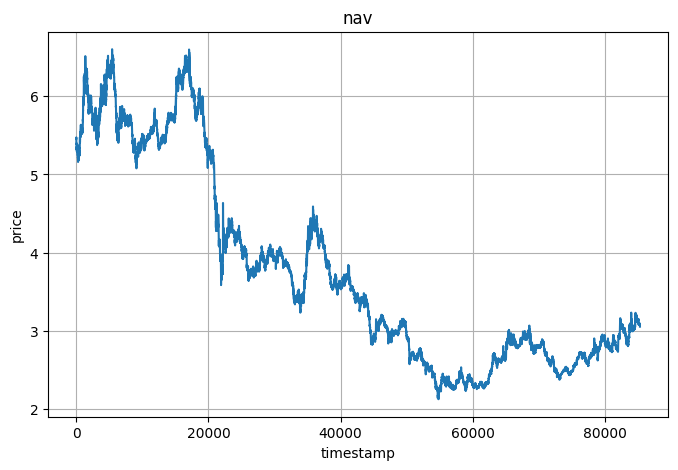

In [7]:
sqrt_prices_wbera = [item['sqrtPriceX96'] for item in data_wbera]
sqrt_prices_wbera = np.array(sqrt_prices_wbera).astype(float)
total_supply_wbera_honey = [item['totalSupply'] for item in data_wbera]
token1IslandBalance = [item['token1BalanceKodiak'] for item in data_wbera]
token0IslandBalance = [item['token0BalanceKodiak'] for item in data_wbera]
timestamp = [item['timestamp'] for item in data_wbera]
timestamp = np.array(timestamp).astype(float)


total_supply_wbera_honey = np.array(total_supply_wbera_honey).astype(float)/10**18
wbera_honey_price = to_price(sqrt_prices_wbera)
WBERAIslandBalance = np.array(token0IslandBalance).astype(float)/10**18
HONEYIslandBalance = np.array(token1IslandBalance).astype(float)/10**18
wbera_frac = WBERAIslandBalance*wbera_honey_price/(WBERAIslandBalance*wbera_honey_price + HONEYIslandBalance)
nav = (WBERAIslandBalance*wbera_honey_price + HONEYIslandBalance)/total_supply_wbera_honey

nect_honey_price = nect_honey_price[4500:]
wbera_honey_price = wbera_honey_price[5000:]
wbera_frac = wbera_frac[5000:]
nav = nav[5000:]
timestamp = timestamp[5000:]

print(nav[0])
print(wbera_honey_price[0])
print(wbera_frac[0])
print(timestamp[0])

plot(
    None,
    wbera_honey_price,
    'timestamp',
    'price',
    'wbera_honey_price'
)

plot(
    None,
    wbera_frac,
    'timestamp',
    'price',
    'wbera_frac'
)

plot(
    None,
    nav,
    'timestamp',
    'price',
    'nav'
)

In [8]:
nav = nav
wbera_honey_price = wbera_honey_price
wbera_frac = wbera_frac
nect_honey_price = nect_honey_price[len(nect_honey_price) - len(nav):]

print(len(nect_honey_price))
print(len(nav))
print(len(wbera_honey_price))
print(len(wbera_frac))

85329
85329
85329
85329


In [9]:
N = int(0.8*len(nav))

df_train = pd.DataFrame({
    'timestamp': timestamp[:N],
    'nav': nav[:N],
    'wbera_frac': wbera_frac[:N],
    'wbera_price': wbera_honey_price[:N],
    'nect_price': nect_honey_price[:N]
})

df_test = pd.DataFrame({
    'timestamp': timestamp[N:],
    'nav': nav[N:],
    'wbera_frac': wbera_frac[N:],
    'wbera_price': wbera_honey_price[N:],
    'nect_price': nect_honey_price[N:]
})

display(df_train)
display(df_test)

df_train.to_csv('wbera_train_data_expanded.csv', index=False)
df_test.to_csv('wbera_test_data_expanded.csv', index=False)

,timestamp,nav,wbera_frac,wbera_price,nect_price
0,1.739814e+09,5.460337,0.499635,6.356507,1.001175
1,1.739815e+09,5.474241,0.499639,6.387829,1.001174
2,1.739815e+09,5.446047,0.499630,6.321612,1.001174
3,1.739815e+09,5.424407,0.499623,6.271335,1.001174
4,1.739815e+09,5.397953,0.499614,6.210105,1.001174
...,...,...,...,...,...
68258,1.753224e+09,2.943111,0.556690,2.430666,0.999156
68259,1.753224e+09,2.943111,0.556690,2.430666,0.999156
68260,1.753224e+09,2.943256,0.556671,2.430882,0.999042
68261,1.753225e+09,2.943256,0.556671,2.430882,0.998968


,timestamp,nav,wbera_frac,wbera_price,nect_price
0,1.753225e+09,2.944404,0.556517,2.432585,0.998970
1,1.753225e+09,2.945843,0.556324,2.434721,0.998818
2,1.753225e+09,2.945843,0.556324,2.434721,0.998467
3,1.753226e+09,2.950460,0.555707,2.441588,0.998002
4,1.753226e+09,2.950460,0.555707,2.441588,0.998077
...,...,...,...,...,...
17061,1.756516e+09,3.073303,0.533178,2.629829,0.998730
17062,1.756516e+09,3.070126,0.533605,2.624732,0.998731
17063,1.756517e+09,3.055626,0.535559,2.601587,0.998773
17064,1.756517e+09,3.055697,0.535550,2.601701,0.998773
